# 🤖 Pertemuan 11 — Python ML: Clustering dengan scikit-learn
### Mata Kuliah: Python Machine Learning

---

## Tujuan Pembelajaran

Setelah pertemuan ini, kamu bisa:
1. Membedakan *unsupervised learning* dari *supervised learning* dan menentukan kapan clustering digunakan
2. Mengimplementasikan K-Means, DBSCAN, dan Agglomerative Hierarchical Clustering dengan scikit-learn
3. Menggunakan metode Elbow dan Silhouette Score untuk menentukan jumlah cluster optimal
4. Menginterpretasikan dendrogram pada Hierarchical Clustering
5. Membandingkan performa tiga algoritma clustering secara kuantitatif

---

## Recap Cepat — Quiz Kilat ⚡

Sebelum mulai, jawab pertanyaan berikut tanpa melihat catatan:

1. Apa perbedaan mendasar antara **supervised learning** (P9–P10) dan **unsupervised learning** (hari ini)?
2. Dari pertemuan lalu: apa itu **R²**? Nilai berapa yang dianggap "model yang baik"?
3. Bayangkan kamu punya data pelanggan (usia, pengeluaran) tanpa label apapun. Algoritma apa yang mungkin berguna?

---

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("✅ Setup selesai!")

✅ Setup selesai!


---

## BAGIAN 1: Apa itu Clustering?

**Clustering** adalah tugas *unsupervised learning* — model mencari **struktur tersembunyi** dalam data **tanpa label**.

```
Supervised (P9–P10):                  Unsupervised (hari ini):
─────────────────────────────         ──────────────────────────────
Input: fitur + LABEL ✅                Input: fitur SAJA (tanpa label)
Output: prediksi label baru            Output: nomor cluster (0, 1, 2, ...)

Contoh:                               Contoh:
  foto kucing → "kucing"                foto kucing+anjing → kelompok A & B
  email → spam/bukan spam              pelanggan → segmen 1, 2, 3
```

**Kapan menggunakan clustering?**

| Permasalahan | Tujuan |
|-------------|--------|
| Segmentasi pelanggan | Temukan kelompok pelanggan dengan perilaku serupa |
| Deteksi anomali | Temukan titik yang tidak masuk cluster manapun |
| Kompresi data | Ganti banyak titik dengan centroid cluster |
| Eksplorasi data | Pahami struktur data sebelum membuat label |
| Rekomendasi | Kelompokkan item/user yang mirip |

```
> Tidak ada jawaban "benar" dalam clustering — hasilnya bergantung pada algoritma,
> parameter, dan interpretasi domain kamu.
```

**Algoritma yang kita pelajari hari ini:**

| Algoritma | Cara Kerja | Kapan Cocok |
|-----------|------------|-------------|
| **K-Means** | Centroid-based, minimasi jarak ke pusat cluster | Data bulat/spherical, jumlah cluster diketahui |
| **DBSCAN** | Density-based, cari region padat | Cluster berbentuk bebas, ada noise/outlier |
| **Agglomerative** | Bottom-up hierarchical merging | Tidak tahu jumlah cluster, butuh dendrogram |

---

## BAGIAN 2: Load Data

Kita gunakan dataset **Iris** — dataset klasik berisi pengukuran bunga dari 3 spesies.

Dataset ini ideal untuk belajar clustering karena:
- Memiliki **3 kelompok alami** (spesies) yang bisa kita verifikasi
- Fiturnya bermakna secara biologi (panjang/lebar kelopak dan mahkota)
- Tersedia langsung di scikit-learn

⚠️ **Penting:** Dalam clustering, kita **tidak menggunakan label** saat melatih model.  
Label spesies hanya dipakai di akhir untuk **memvalidasi** apakah hasil cluster masuk akal.

**Fitur yang tersedia:**

| Nama Kolom | Deskripsi |
|-----------|----------|
| `sepal_length` | Panjang kelopak (cm) |
| `sepal_width` | Lebar kelopak (cm) |
| `petal_length` | Panjang mahkota (cm) |
| `petal_width` | Lebar mahkota (cm) |
| `species` | *(Label — TIDAK digunakan saat training)* |

In [2]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df['species']       = iris.target
df['species_name']  = [iris.target_names[i] for i in iris.target]

print("✅ Dataset berhasil dimuat!")
print(f"\nUkuran dataset: {df.shape}")
print(f"\nJumlah sampel per spesies:")
print(df['species_name'].value_counts().to_string())
print(f"\nDeskripsi singkat:")
df.drop(columns=['species', 'species_name']).describe().round(2)

✅ Dataset berhasil dimuat!

Ukuran dataset: (150, 6)

Jumlah sampel per spesies:
species_name
setosa        50
versicolor    50
virginica     50

Deskripsi singkat:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


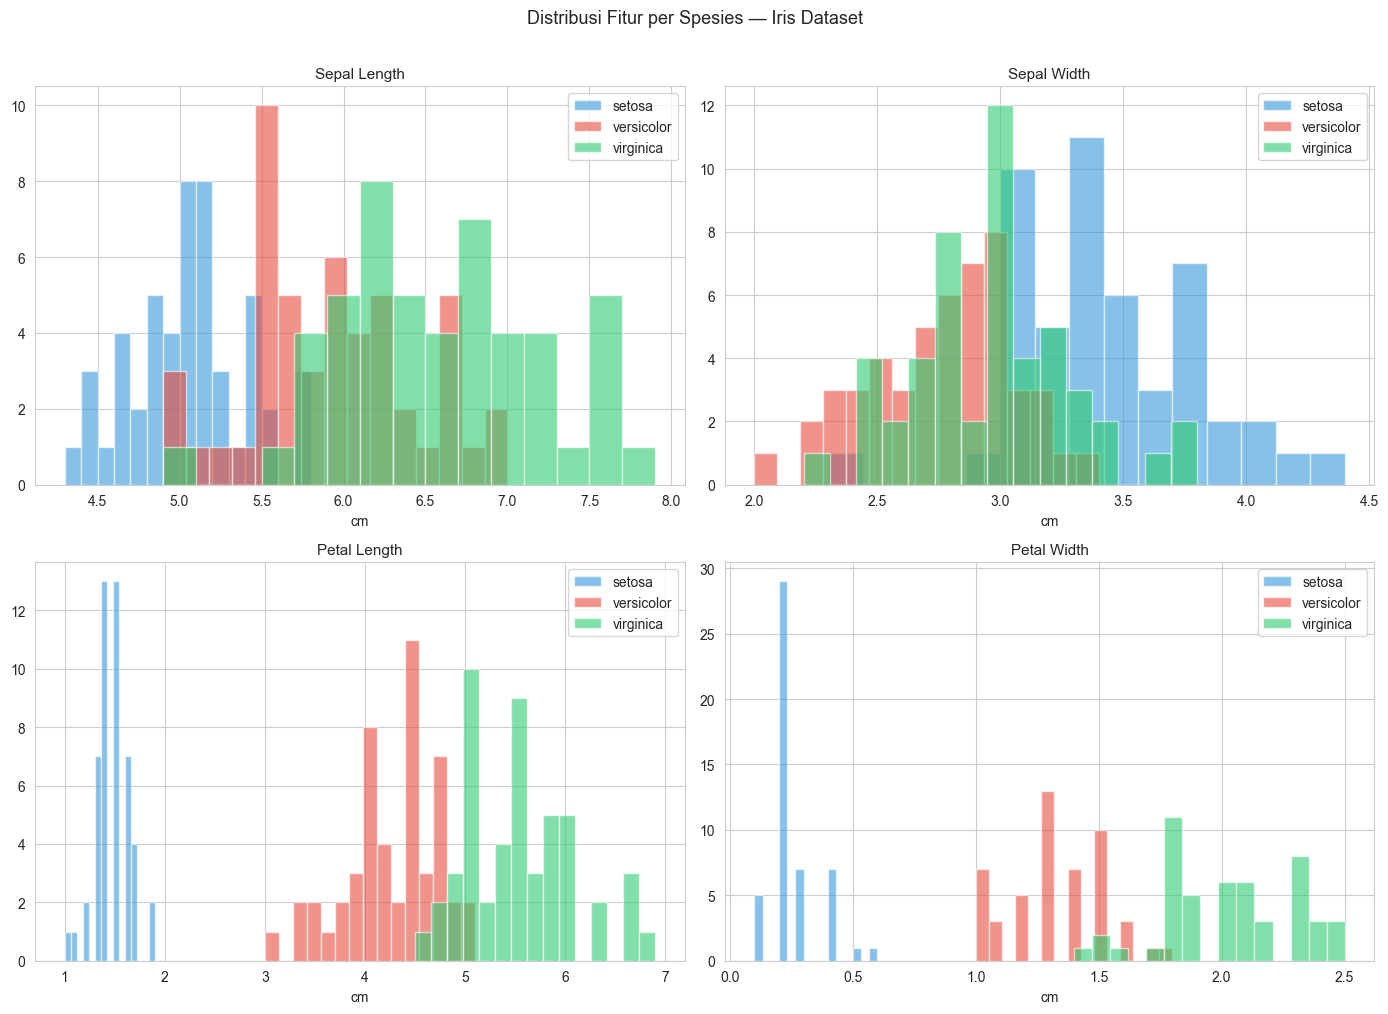

Catatan: Setosa terlihat mudah dipisahkan; Versicolor dan Virginica saling tumpang tindih.


In [3]:
# Visualisasi distribusi fitur per spesies (pakai label hanya untuk EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fitur = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
warna = {'setosa': '#3498db', 'versicolor': '#e74c3c', 'virginica': '#2ecc71'}

for ax, f in zip(axes.flatten(), fitur):
    for spesies, grp in df.groupby('species_name'):
        ax.hist(grp[f], bins=15, alpha=0.6, label=spesies, color=warna[spesies], edgecolor='white')
    ax.set_title(f.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('cm')
    ax.legend()

plt.suptitle('Distribusi Fitur per Spesies — Iris Dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Catatan: Setosa terlihat mudah dipisahkan; Versicolor dan Virginica saling tumpang tindih.")

Data asli: (150, 4)
Data setelah scaling: (150, 4)
Data setelah PCA (2D): (150, 2)

Variansi yang dipertahankan PCA: 95.8%

📌 PCA digunakan HANYA untuk visualisasi 2D.
   Model clustering tetap dilatih pada data 4D yang sudah discaling.


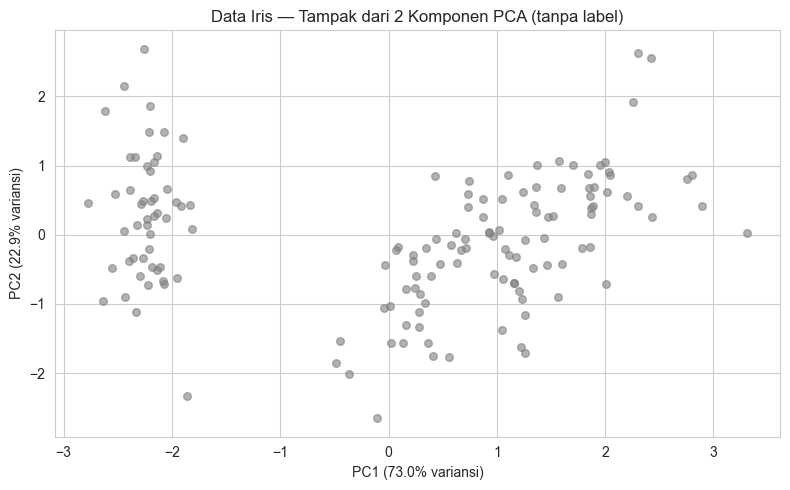

In [4]:
# Persiapkan data untuk clustering (TANPA label)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y_true = df['species'].values  # disimpan untuk validasi di akhir

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduksi ke 2D untuk visualisasi (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Data asli: {X.shape}")
print(f"Data setelah scaling: {X_scaled.shape}")
print(f"Data setelah PCA (2D): {X_pca.shape}")
print(f"\nVariansi yang dipertahankan PCA: {pca.explained_variance_ratio_.sum():.1%}")
print("\n📌 PCA digunakan HANYA untuk visualisasi 2D.")
print("   Model clustering tetap dilatih pada data 4D yang sudah discaling.")

# Plot data tanpa label (simulasi kondisi nyata)
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='gray', s=30)
plt.title('Data Iris — Tampak dari 2 Komponen PCA (tanpa label)', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variansi)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variansi)')
plt.tight_layout()
plt.show()

---

## BAGIAN 3: Model
### K-Means

**K-Means** adalah algoritma clustering paling populer. Ia membagi data menjadi **K cluster** dengan cara meminimalkan jarak setiap titik ke **centroid** (pusat) cluster-nya.

```
Algoritma (iteratif):

  1. Inisialisasi: tempatkan K centroid secara acak
  2. Assignment: setiap titik → cluster centroid terdekat
  3. Update: geser centroid ke rata-rata cluster-nya
  4. Ulangi 2–3 sampai centroid tidak bergerak lagi

  Iterasi 1:          Iterasi 2:          Konvergen:
  ● ● × ■ ■          ● ● ● ■ ■          ● ● ● ■ ■
  ● × × ■ ■    →     ● ● × ■ ■    →     ● ● ● ■ ■
  × × × ■ ■          × × × ■ ■          × × × ■ ■
  (×=centroid)        (centroid bergeser)  (stabil)
```

**Parameter penting:**
- `n_clusters` (K): **jumlah cluster** — harus ditentukan di awal
- `init='k-means++'`: inisialisasi centroid yang lebih cerdas (default)
- `n_init`: berapa kali algoritma dijalankan ulang (ambil hasil terbaik)

**Kelemahan:**
- Harus tentukan K di awal
- Sensitif terhadap outlier
- Hanya bekerja baik untuk cluster berbentuk bulat (spherical)

In [5]:
# Latih K-Means dengan K=3 (kita tahu dari konteks ada 3 spesies)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

labels_km = kmeans.labels_
print(f"Cluster yang terbentuk: {np.unique(labels_km)}")
print(f"Jumlah titik per cluster:")
for c in np.unique(labels_km):
    print(f"  Cluster {c}: {(labels_km == c).sum()} titik")
print(f"\nInertia (WCSS): {kmeans.inertia_:.4f}")

Cluster yang terbentuk: [0 1 2]
Jumlah titik per cluster:
  Cluster 0: 53 titik
  Cluster 1: 50 titik
  Cluster 2: 47 titik

Inertia (WCSS): 139.8205


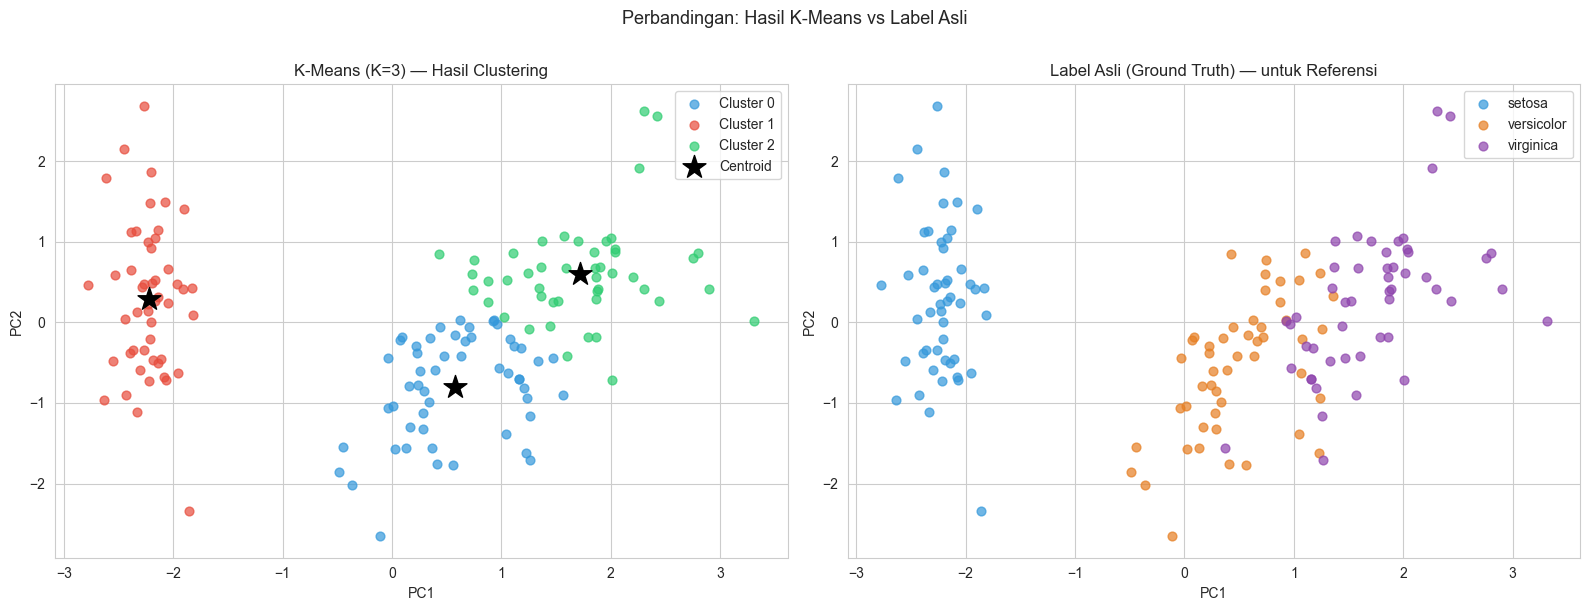


💡 Nomor cluster tidak harus sama dengan nomor spesies — yang penting strukturnya mirip!


In [6]:
# Visualisasi hasil K-Means
warna_cluster = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot cluster hasil K-Means
for c in np.unique(labels_km):
    mask = labels_km == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.7, s=40, color=warna_cluster[c], label=f'Cluster {c}')

# Plot centroid
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='*', s=300, color='black', zorder=5, label='Centroid')
axes[0].set_title('K-Means (K=3) — Hasil Clustering', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot label asli untuk perbandingan
nama_spesies = iris.target_names
warna_spesies = ['#3498db', '#e67e22', '#8e44ad']
for s in range(3):
    mask = y_true == s
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.7, s=40, color=warna_spesies[s], label=nama_spesies[s])
axes[1].set_title('Label Asli (Ground Truth) — untuk Referensi', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Perbandingan: Hasil K-Means vs Label Asli', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Nomor cluster tidak harus sama dengan nomor spesies — yang penting strukturnya mirip!")

---

#### Metode Elbow — Menentukan K Optimal

K-Means butuh **K sebagai input**. Jika kita tidak tahu berapa cluster yang tepat, gunakan **Elbow Method**:

```
Inertia (WCSS):        
↑                      
|●                     
| ●                    ← "Siku" (elbow) adalah K optimal:
|  ●                      penambahan cluster setelahnya
|    ●                     tidak mengurangi inertia secara signifikan
|      ● ● ● ● ● ● 
+──────────────────→ K
   1 2 3 4 5 6 7
```

Pilih K di titik "siku" — di mana penurunan inertia mulai melandai.

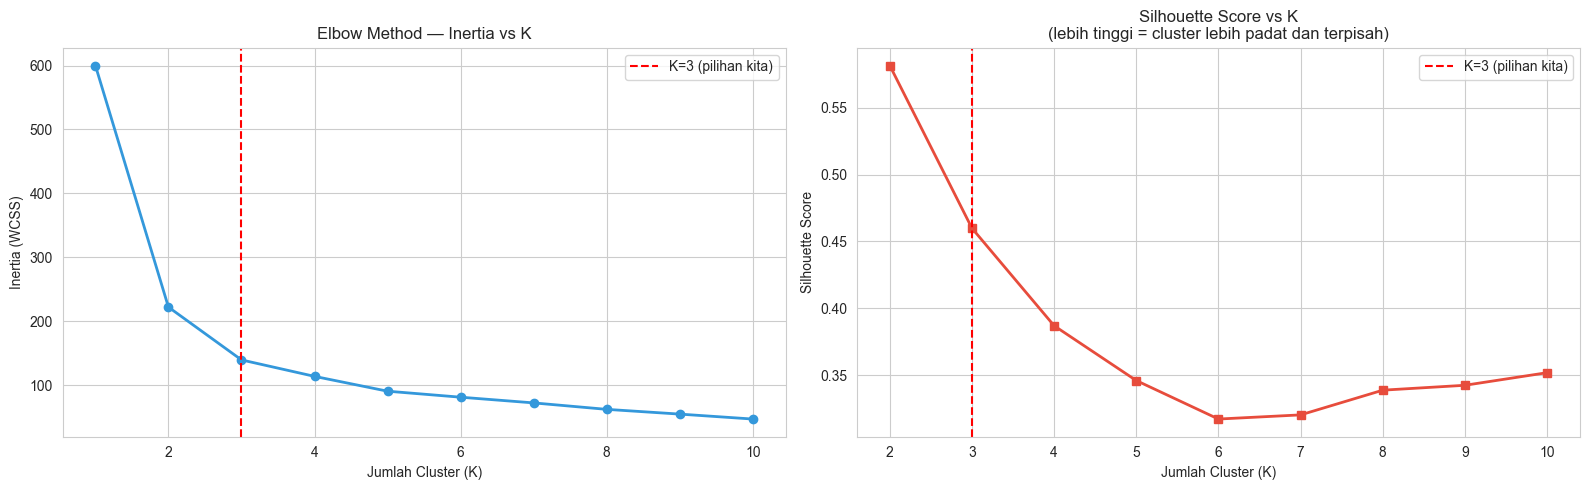

K dengan Silhouette Score tertinggi: 2


In [7]:
# Elbow Method: inertia vs jumlah cluster
k_range  = range(1, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_scaled, km.labels_))
    else:
        silhouettes.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'o-', color='#3498db', linewidth=2)
axes[0].axvline(3, color='red', linestyle='--', label='K=3 (pilihan kita)')
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=12)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

# Silhouette Score vs K
axes[1].plot(range(2, 11), silhouettes[1:], 's-', color='#e74c3c', linewidth=2)
axes[1].axvline(3, color='red', linestyle='--', label='K=3 (pilihan kita)')
axes[1].set_title('Silhouette Score vs K\n(lebih tinggi = cluster lebih padat dan terpisah)', fontsize=12)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = range(2, 11)[np.argmax(silhouettes[1:])]
print(f"K dengan Silhouette Score tertinggi: {best_k}")

---

### DBSCAN

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) bekerja dengan cara menemukan **region padat** dalam data — bukan membagi berdasarkan jarak ke centroid.

```
Konsep utama:

  ● = Core point   (punya ≥ min_samples tetangga dalam radius eps)
  ○ = Border point (dalam radius eps core point, tapi tetangga sedikit)
  × = Noise point  (tidak termasuk cluster manapun → label = -1)

  ● ● ● ○ ○            ● ● ●                  
  ● ● ● ○          →  cluster A   ×   cluster B
  ● ○   × ○ ○                         ○ ○
            ● ● ●                    ● ● ●
```

**Parameter penting:**
- `eps`: radius lingkungan — seberapa dekat agar dianggap "tetangga"
- `min_samples`: minimum titik dalam radius `eps` agar jadi *core point*

**Keunggulan dibanding K-Means:**
- Tidak perlu tentukan jumlah cluster di awal
- Bisa menemukan cluster berbentuk bebas (non-spherical)
- Otomatis tandai outlier sebagai noise (label = -1)

**Kelemahan:**
- Sensitif terhadap pilihan `eps` dan `min_samples`
- Kurang efektif untuk data berdimensi tinggi

In [8]:
# Latih DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled)

labels_db = dbscan.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()

print(f"Cluster yang terbentuk: {n_clusters_db}")
print(f"Titik noise (label=-1): {n_noise_db}")
print(f"\nJumlah titik per cluster:")
for c in sorted(set(labels_db)):
    label = f'Cluster {c}' if c != -1 else 'Noise'
    print(f"  {label}: {(labels_db == c).sum()} titik")

Cluster yang terbentuk: 2
Titik noise (label=-1): 34

Jumlah titik per cluster:
  Noise: 34 titik
  Cluster 0: 45 titik
  Cluster 1: 71 titik


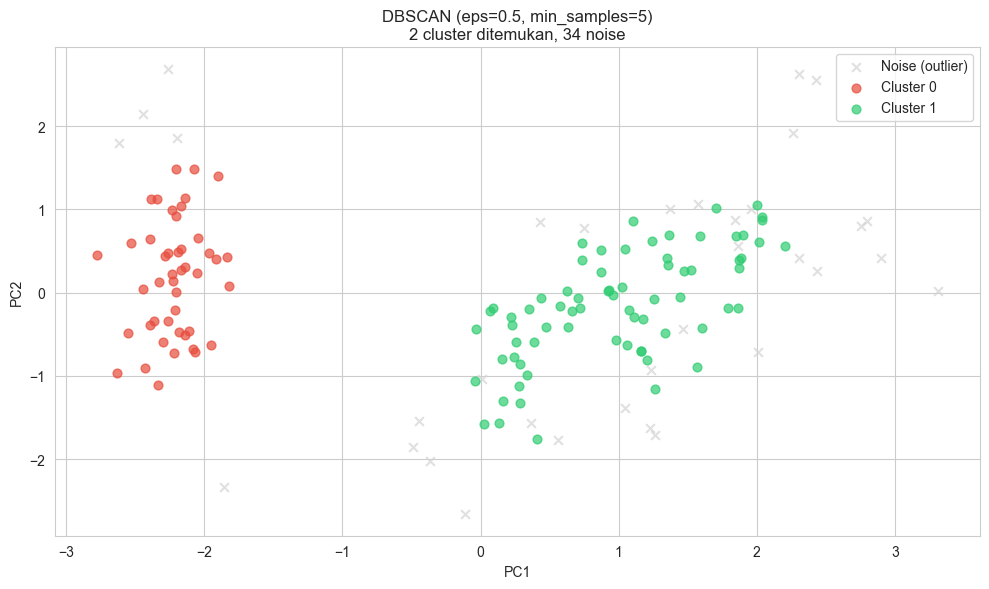

In [9]:
# Visualisasi hasil DBSCAN
plt.figure(figsize=(10, 6))

unique_labels = sorted(set(labels_db))
palet = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, c in enumerate(unique_labels):
    mask  = labels_db == c
    warna = 'lightgray' if c == -1 else palet[i % len(palet)]
    label = 'Noise (outlier)' if c == -1 else f'Cluster {c}'
    marker = 'x' if c == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.7, s=40, color=warna, label=label, marker=marker)

plt.title(f'DBSCAN (eps=0.5, min_samples=5)\n{n_clusters_db} cluster ditemukan, {n_noise_db} noise', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

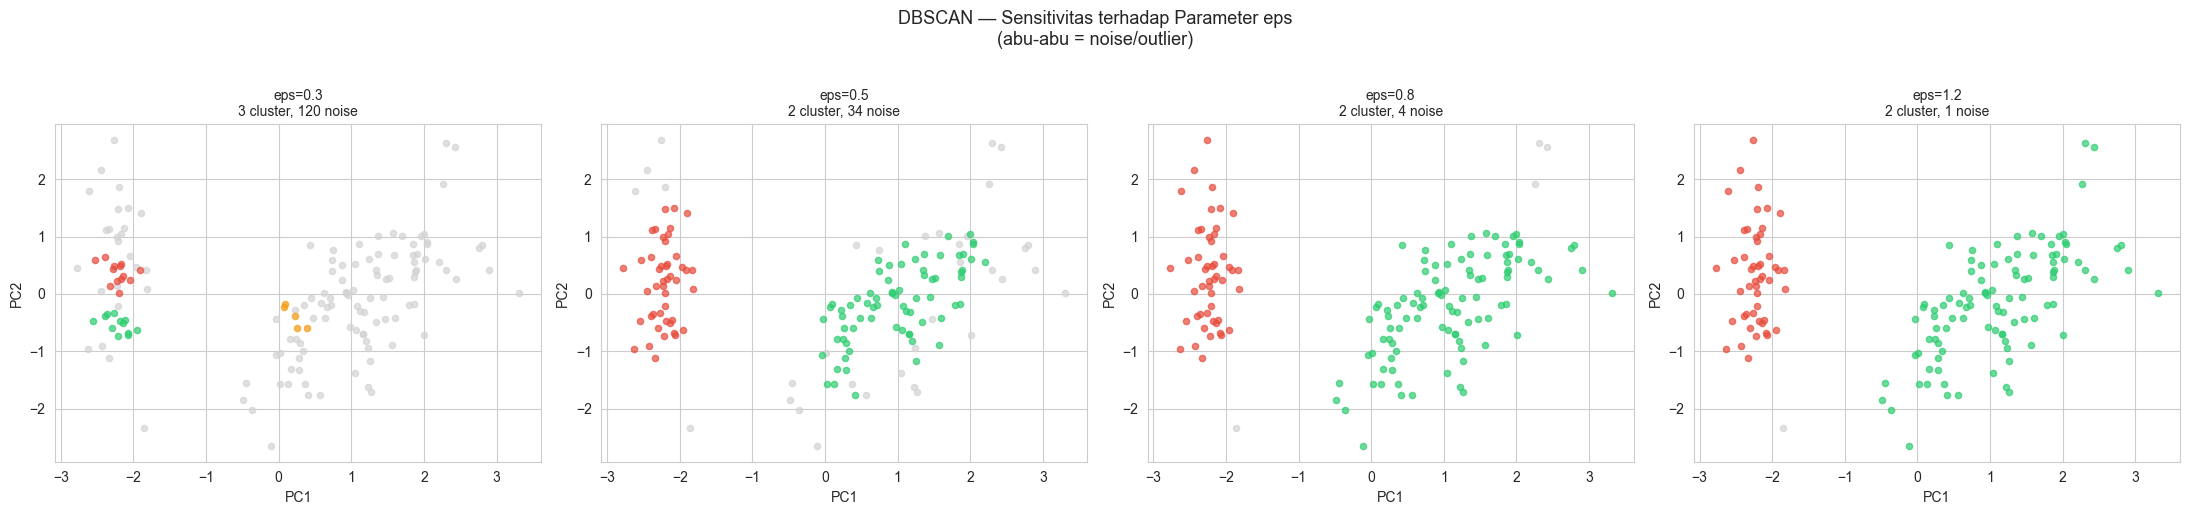


💡 eps terlalu kecil → terlalu banyak noise.  eps terlalu besar → semua jadi 1 cluster.
   Gunakan k-distance graph atau domain knowledge untuk memilih eps yang tepat.


In [10]:
# Eksperimen: Pengaruh eps terhadap jumlah cluster DBSCAN
eps_values = [0.3, 0.5, 0.8, 1.2]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(X_scaled)
    lbl = db.labels_
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_n = (lbl == -1).sum()

    for i, c in enumerate(sorted(set(lbl))):
        mask  = lbl == c
        warna = 'lightgray' if c == -1 else palet[i % len(palet)]
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   alpha=0.7, s=20, color=warna)

    ax.set_title(f'eps={eps}\n{n_c} cluster, {n_n} noise', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('DBSCAN — Sensitivitas terhadap Parameter eps\n(abu-abu = noise/outlier)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 eps terlalu kecil → terlalu banyak noise.  eps terlalu besar → semua jadi 1 cluster.")
print("   Gunakan k-distance graph atau domain knowledge untuk memilih eps yang tepat.")

---

### Agglomerative Hierarchical Clustering

**Agglomerative Clustering** membangun hierarki cluster secara **bottom-up**: mulai dari setiap titik sebagai cluster sendiri, lalu gabungkan yang terdekat secara berulang.

```
Proses (bottom-up):

  Awal: A  B  C  D  E  (5 cluster, masing-masing 1 titik)
           ↓
  Step 1:  [AB]  C  D  E    (A dan B paling dekat, digabung)
           ↓
  Step 2:  [AB]  C  [DE]    (D dan E digabung)
           ↓
  Step 3:  [ABC]  [DE]      (C bergabung ke cluster AB)
           ↓
  Step 4:  [ABCDE]          (semua jadi 1 cluster)
```

Proses ini divisualisasikan sebagai **Dendrogram** — pohon hierarki yang menunjukkan urutan penggabungan.

**Parameter penting:**
- `n_clusters`: potong dendrogram di level yang menghasilkan K cluster
- `linkage`: cara mengukur jarak antar cluster (`ward`, `complete`, `average`, `single`)

**Keunggulan:**
- Tidak perlu tentukan K di awal (bisa pilih setelah melihat dendrogram)
- Dendrogram memberi insight hierarki yang kaya
- Deterministik (tidak ada inisialisasi acak)

**Kelemahan:**
- Lambat untuk dataset besar (O(n³))
- Sekali digabung, cluster tidak bisa dipisah lagi

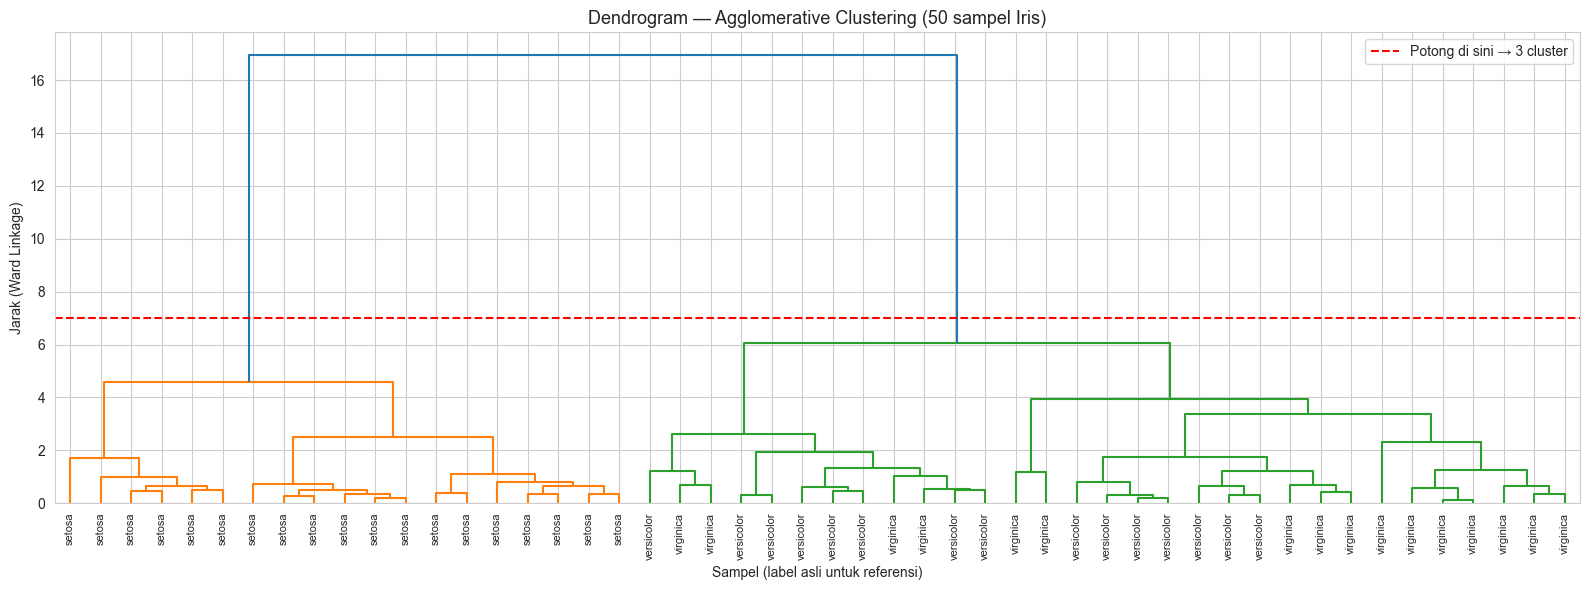


💡 Garis horizontal merah menunjukkan di mana kita 'memotong' dendrogam.
   Jumlah cabang yang dipotong = jumlah cluster yang dihasilkan.


In [11]:
# Visualisasi Dendrogram (pakai subset 50 sampel agar terbaca)
subset_idx = np.random.RandomState(42).choice(len(X_scaled), 50, replace=False)
X_sub      = X_scaled[subset_idx]
label_sub  = [iris.target_names[y_true[i]] for i in subset_idx]

Z = linkage(X_sub, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=label_sub,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=7
)
plt.title('Dendrogram — Agglomerative Clustering (50 sampel Iris)', fontsize=13)
plt.xlabel('Sampel (label asli untuk referensi)')
plt.ylabel('Jarak (Ward Linkage)')
plt.axhline(7, color='red', linestyle='--', label='Potong di sini → 3 cluster')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Garis horizontal merah menunjukkan di mana kita 'memotong' dendrogam.")
print("   Jumlah cabang yang dipotong = jumlah cluster yang dihasilkan.")

In [12]:
# Latih Agglomerative Clustering pada seluruh data
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo.fit(X_scaled)

labels_ag = agglo.labels_
print(f"Cluster yang terbentuk: {np.unique(labels_ag)}")
print(f"Jumlah titik per cluster:")
for c in np.unique(labels_ag):
    print(f"  Cluster {c}: {(labels_ag == c).sum()} titik")

Cluster yang terbentuk: [0 1 2]
Jumlah titik per cluster:
  Cluster 0: 71 titik
  Cluster 1: 49 titik
  Cluster 2: 30 titik


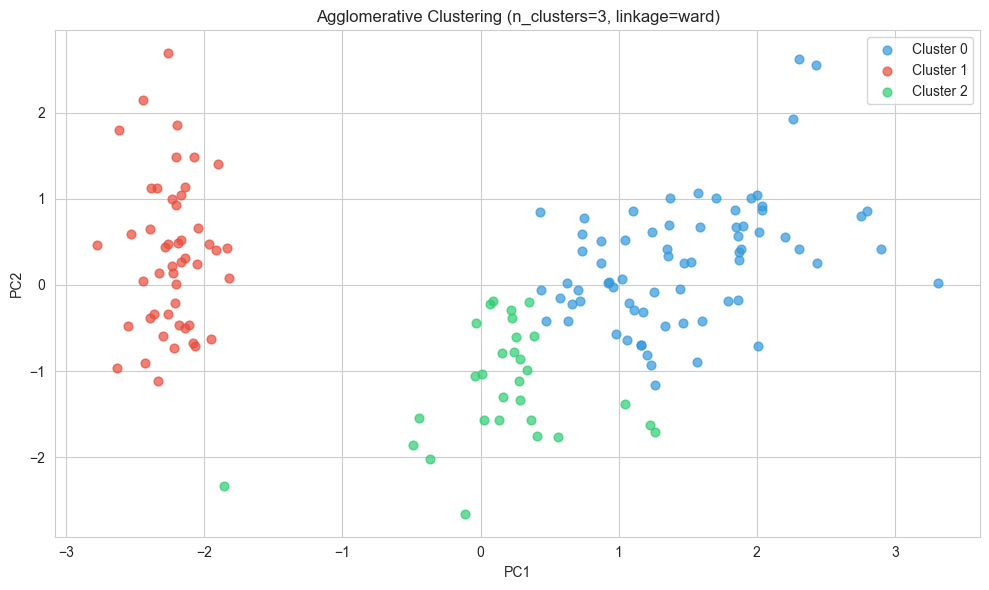

In [13]:
# Visualisasi hasil Agglomerative Clustering
plt.figure(figsize=(10, 6))

for c in np.unique(labels_ag):
    mask = labels_ag == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.7, s=40, color=warna_cluster[c], label=f'Cluster {c}')

plt.title('Agglomerative Clustering (n_clusters=3, linkage=ward)', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

---

## BAGIAN 4: Evaluasi Model

### Metrik Clustering

Clustering lebih sulit dievaluasi karena **tidak ada label "benar"**. Kita punya dua jenis metrik:

#### A. Metrik Internal (tanpa ground truth)

Mengukur kualitas cluster berdasarkan struktur data itu sendiri.

| Metrik | Formula (intuitif) | Interpretasi | Terbaik |
|--------|-------------------|--------------|--------|
| **Silhouette Score** | (jarak ke cluster lain − jarak dalam cluster) / max | Seberapa padat & terpisah cluster | Tinggi (+1 = sempurna, 0 = tumpang tindih, -1 = salah cluster) |
| **Davies-Bouldin Score** | rata-rata rasio diameter cluster / jarak antar cluster | Seberapa kompak & berjauhan cluster | Rendah (0 = sempurna) |
| **Inertia (WCSS)** | Σ jarak² titik ke centroid-nya | Kerapatan dalam cluster (K-Means only) | Rendah |

#### B. Metrik Eksternal (dengan ground truth — jika ada)

Mengukur seberapa mirip hasil clustering dengan label yang diketahui.

| Metrik | Interpretasi | Range |
|--------|--------------|-------|
| **ARI** (Adjusted Rand Index) | Seberapa cocok clustering dengan label asli | -1 sampai 1 (1 = sempurna) |
| **NMI** (Normalized Mutual Info) | Shared information antara cluster dan label | 0 sampai 1 (1 = sempurna) |

> **Catatan:** ARI dan NMI hanya bisa dihitung jika kita TAHU label asli (seperti dataset Iris).  
> Dalam kasus nyata (tanpa label), gunakan Silhouette dan Davies-Bouldin.

In [14]:
# Hitung semua metrik untuk ketiga algoritma
# Catatan: DBSCAN kadang hasilkan cluster < 2 atau semua noise — tangani edge case

def hitung_metrik(X, labels, y_true, nama):
    valid = labels != -1  # abaikan noise untuk metrik internal
    n_cluster = len(set(labels[valid]))

    if n_cluster < 2:
        return {'Model': nama, 'N Cluster': n_cluster,
                'Silhouette': np.nan, 'Davies-Bouldin': np.nan,
                'ARI': np.nan, 'NMI': np.nan}

    return {
        'Model'          : nama,
        'N Cluster'      : n_cluster,
        'Silhouette'     : round(silhouette_score(X[valid], labels[valid]),      4),
        'Davies-Bouldin' : round(davies_bouldin_score(X[valid], labels[valid]),  4),
        'ARI'            : round(adjusted_rand_score(y_true, labels),            4),
        'NMI'            : round(normalized_mutual_info_score(y_true, labels),   4),
    }

hasil = [
    hitung_metrik(X_scaled, labels_km, y_true, 'K-Means (K=3)'),
    hitung_metrik(X_scaled, labels_db, y_true, 'DBSCAN (eps=0.5)'),
    hitung_metrik(X_scaled, labels_ag, y_true, 'Agglomerative (ward)'),
]

df_hasil = pd.DataFrame(hasil)
print("=" * 70)
print("PERBANDINGAN METRIK — 3 ALGORITMA CLUSTERING")
print("=" * 70)
print(df_hasil.to_string(index=False))
print("\n📌 Silhouette: makin tinggi makin baik (max +1)")
print("   Davies-Bouldin: makin rendah makin baik (min 0)")
print("   ARI & NMI: makin tinggi makin cocok dengan label asli (max 1)")

PERBANDINGAN METRIK — 3 ALGORITMA CLUSTERING
               Model  N Cluster  Silhouette  Davies-Bouldin    ARI    NMI
       K-Means (K=3)          3      0.4599          0.8336 0.6201 0.6595
    DBSCAN (eps=0.5)          2      0.6559          0.4942 0.4421 0.5114
Agglomerative (ward)          3      0.4467          0.8035 0.6153 0.6755

📌 Silhouette: makin tinggi makin baik (max +1)
   Davies-Bouldin: makin rendah makin baik (min 0)
   ARI & NMI: makin tinggi makin cocok dengan label asli (max 1)


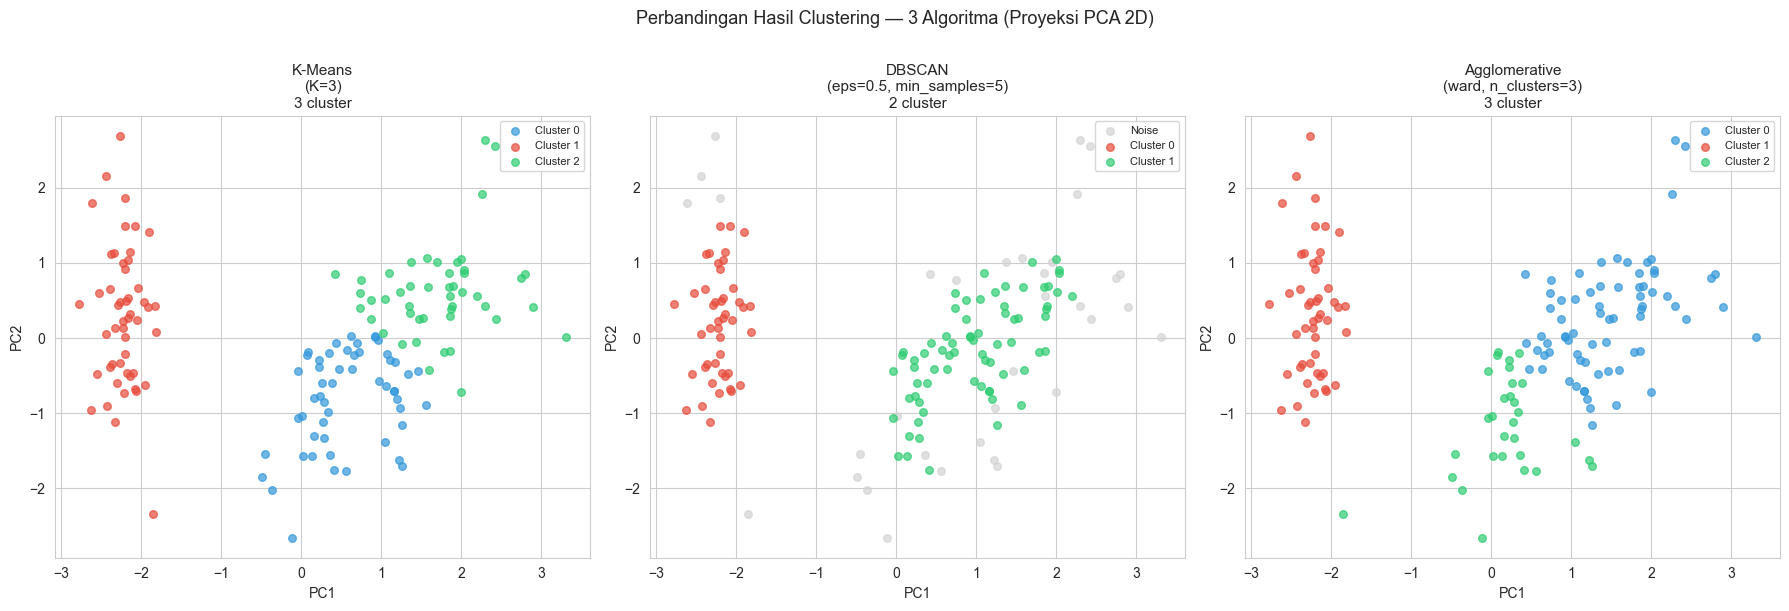

In [15]:
# Visualisasi perbandingan hasil ketiga model berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_viz = [
    (labels_km, 'K-Means\n(K=3)'),
    (labels_db, 'DBSCAN\n(eps=0.5, min_samples=5)'),
    (labels_ag, 'Agglomerative\n(ward, n_clusters=3)'),
]

for ax, (lbl, nama) in zip(axes, models_viz):
    unique = sorted(set(lbl))
    for i, c in enumerate(unique):
        mask  = lbl == c
        warna = 'lightgray' if c == -1 else warna_cluster[i % len(warna_cluster)]
        label = 'Noise' if c == -1 else f'Cluster {c}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   alpha=0.7, s=30, color=warna, label=label)
    n_c = len(unique) - (1 if -1 in unique else 0)
    ax.set_title(f'{nama}\n{n_c} cluster', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle('Perbandingan Hasil Clustering — 3 Algoritma (Proyeksi PCA 2D)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

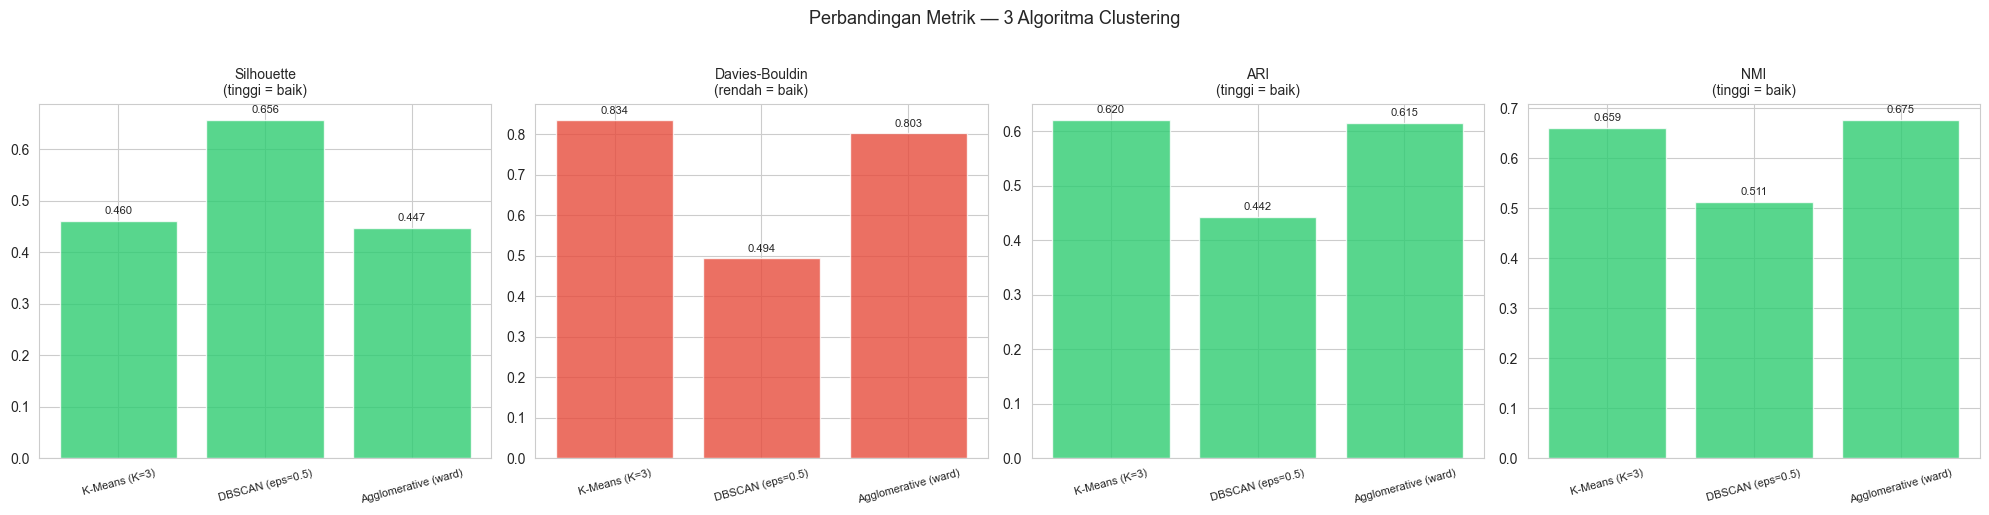

In [16]:
# Visualisasi metrik sebagai bar chart
metrik_plot = df_hasil.dropna().set_index('Model')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, arah) in zip(axes, [
    ('Silhouette',     'tinggi = baik'),
    ('Davies-Bouldin', 'rendah = baik'),
    ('ARI',            'tinggi = baik'),
    ('NMI',            'tinggi = baik'),
]):
    if col in metrik_plot.columns:
        warna_bar = '#2ecc71' if 'tinggi' in arah else '#e74c3c'
        bars = ax.bar(range(len(metrik_plot)), metrik_plot[col],
                      color=warna_bar, alpha=0.8, edgecolor='white')
        ax.set_xticks(range(len(metrik_plot)))
        ax.set_xticklabels(metrik_plot.index, rotation=15, fontsize=8)
        ax.set_title(f'{col}\n({arah})', fontsize=10)
        for bar, val in zip(bars, metrik_plot[col]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perbandingan Metrik — 3 Algoritma Clustering', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

### Silhouette Analysis — Per Cluster

Selain Silhouette Score keseluruhan, kita bisa melihat **distribusi silhouette per titik** dalam setiap cluster untuk mendeteksi cluster yang kurang baik.

```
Silhouette tiap titik:

  Cluster 0: ████████████████  (silhouette tinggi → cluster padat, terpisah baik)
  Cluster 1: ████████          (silhouette sedang → ada tumpang tindih)
  Cluster 2: ██████████████    (silhouette tinggi)
  ─────────────────────────────
  Garis putus = skor rata-rata keseluruhan
```

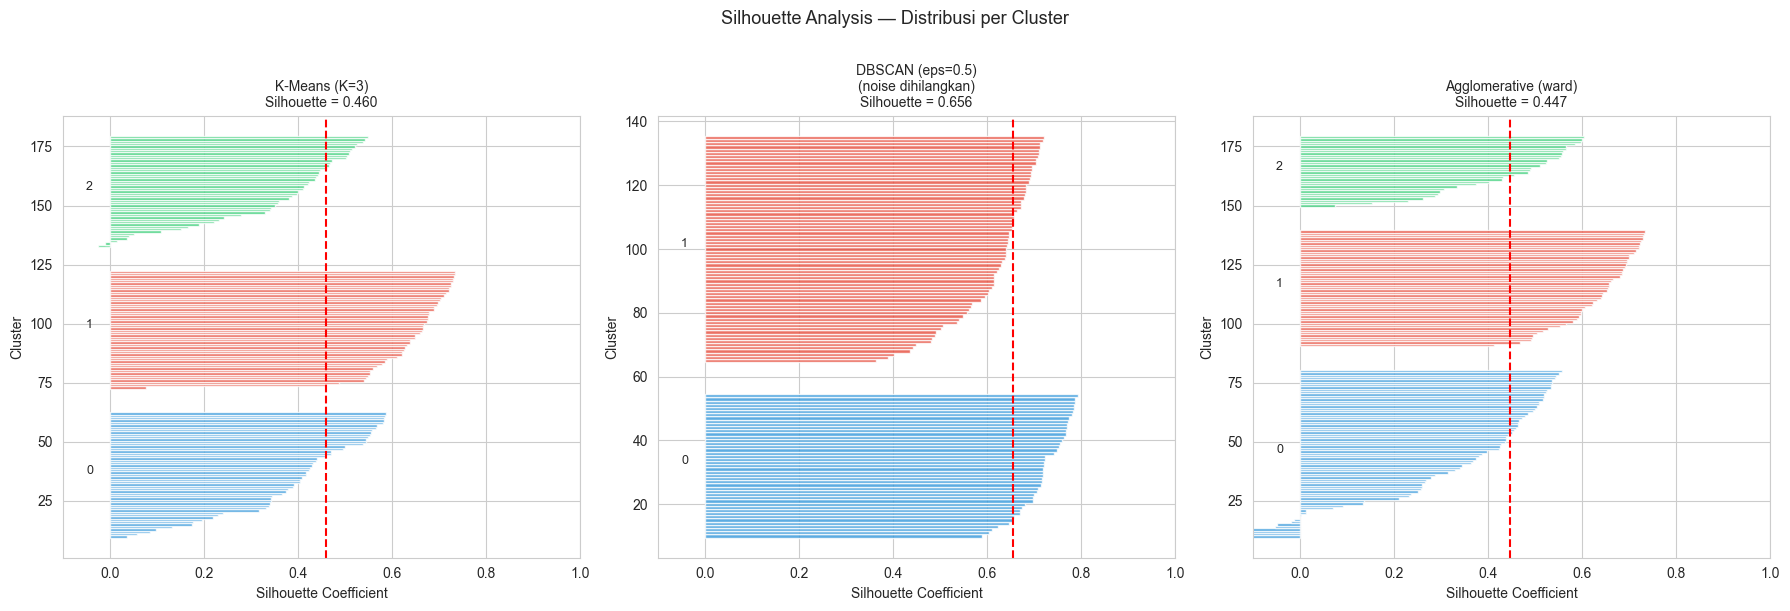


💡 Cluster yang ideal: semua bar melewati garis merah (rata-rata) dan tidak ada nilai negatif.


In [17]:
from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_sil = [
    (labels_km, 'K-Means (K=3)'),
    (labels_ag, 'Agglomerative (ward)'),
]

# Untuk DBSCAN, filter noise dulu
mask_db  = labels_db != -1
models_sil_db = [(labels_db[mask_db], 'DBSCAN (eps=0.5)')]

all_models = [
    (X_scaled,         labels_km,           'K-Means (K=3)'),
    (X_scaled[mask_db], labels_db[mask_db], 'DBSCAN (eps=0.5)\n(noise dihilangkan)'),
    (X_scaled,         labels_ag,           'Agglomerative (ward)'),
]

for ax, (X_m, lbl, nama) in zip(axes, all_models):
    n_c = len(set(lbl))
    if n_c < 2:
        ax.set_title(f'{nama}\ntidak bisa dihitung')
        continue

    sil_vals   = silhouette_samples(X_m, lbl)
    avg_score  = sil_vals.mean()
    y_lower = 10

    for c in sorted(set(lbl)):
        vals_c = np.sort(sil_vals[lbl == c])
        size_c = vals_c.shape[0]
        y_upper = y_lower + size_c
        ax.barh(range(y_lower, y_upper), vals_c,
                height=1.0, color=warna_cluster[c % len(warna_cluster)], alpha=0.8)
        ax.text(-0.05, y_lower + size_c / 2, str(c), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(avg_score, color='red', linestyle='--')
    ax.set_title(f'{nama}\nSilhouette = {avg_score:.3f}', fontsize=10)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_xlim(-0.1, 1.0)

plt.suptitle('Silhouette Analysis — Distribusi per Cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Cluster yang ideal: semua bar melewati garis merah (rata-rata) dan tidak ada nilai negatif.")

---

## ✏️ Latihan Mandiri

Kerjakan soal berikut menggunakan **dataset tim kamu sendiri** (bukan Iris):

In [ ]:
# LATIHAN 1: Ganti dengan dataset timmu
# 1. Load dataset tim kamu (pilih kolom numerik yang relevan)
# 2. Lakukan preprocessing: drop null, scaling dengan StandardScaler
# 3. Jalankan K-Means dengan K=3
# 4. Buat scatter plot hasil clustering (gunakan PCA jika fitur > 2)
# 5. Cetak Silhouette Score dan Davies-Bouldin Score

# Tulis kode di sini:


In [ ]:
# LATIHAN 2: Tentukan K optimal dengan Elbow Method + Silhouette
# 1. Jalankan K-Means untuk K = 2 sampai 10 menggunakan dataset timmu
# 2. Plot Elbow curve (inertia vs K)
# 3. Plot Silhouette Score vs K
# 4. Tentukan K terbaik dan jelaskan alasannya

# Tulis kode di sini:


In [ ]:
# LATIHAN 3 (Tantangan): Bandingkan tiga algoritma
# 1. Jalankan K-Means, DBSCAN, dan Agglomerative pada dataset timmu
# 2. Buat tabel perbandingan Silhouette dan Davies-Bouldin Score
# 3. Buat visualisasi cluster ketiga algoritma berdampingan
# 4. Tulis 3–4 kalimat analisis:
#    - Algoritma mana yang menghasilkan cluster paling bermakna?
#    - Apakah ada titik yang ditandai sebagai noise oleh DBSCAN?
#    - Apa interpretasi bisnis dari cluster yang kamu temukan?

# Tulis kode dan analisis di sini:


---

## 📝 Ringkasan Pertemuan 11

```
CLUSTERING — ALUR LENGKAP

DATA TANPA LABEL
    ↓
[P11] Preprocessing
        ├── Drop null
        ├── Pilih fitur numerik
        └── StandardScaler (WAJIB untuk K-Means & DBSCAN)
    ↓
[P11] Pilih Algoritma Clustering
        ├── K-Means           → cluster bulat, K diketahui, skala besar
        ├── DBSCAN            → cluster bebas bentuk, ada noise/outlier
        └── Agglomerative     → butuh dendrogram, K tidak diketahui
    ↓
[P11] model.fit(X_scaled)
    ↓
[P11] Evaluasi (tanpa label)
        ├── Silhouette Score  → tinggi = cluster padat & terpisah
        ├── Davies-Bouldin    → rendah = cluster kompak & berjauhan
        └── Inertia           → rendah = K-Means fit bagus
    ↓
[P11] Interpretasi
        ├── Beri nama cluster (bukan angka) berdasarkan domain
        └── Validasi dengan stakeholder / domain expert
```

### Supervised vs Unsupervised — Ringkasan Lengkap

| Aspek | Klasifikasi (P9) | Regresi (P10) | Clustering (P11) |
|-------|-----------------|---------------|------------------|
| **Label** | Ya (kategori) | Ya (angka) | Tidak |
| **Output** | Kategori | Angka kontinu | Nomor cluster |
| **Metrik** | Accuracy, F1 | RMSE, R² | Silhouette, DBI |
| **Contoh** | Titanic survived? | Harga rumah? | Segmen pelanggan |
| **Algoritma** | LR, DTC, RFC | LR, DTR, RFR | K-Means, DBSCAN, Agglo |

---

**Pertemuan berikutnya: Python ML — Dimensionality Reduction & Presentasi Project Akhir** 📊  
Dari clustering → teknik PCA dan t-SNE untuk eksplorasi dan visualisasi data berdimensi tinggi